# 🥑 AguaVerde — Experimento D: Gaussian Process por Parcela y por Terreno
## Justificación de umbrales NDMI sin recurrir a un percentil arbitrario

**Equipo 16 · Proyecto Integrador · Jalisco, México**

> Este notebook nace de la reunión de revisión con los profesores asesores
> (2026-06-18): se cuestionó que el umbral NDMI usado para etiquetar
> estrés hídrico (decil/percentil fijo) es arbitrario, y se sugirió ajustar
> una distribución (gaussiana / Gaussian Process) por parcela o por grupo
> de parcelas similares, vía *maximum likelihood*, y clasificar por
> desviaciones estándar respecto a lo esperado — no por un corte fijo.

### Estructura del notebook

| # | Sección | Qué responde |
|---|---------|--------------|
| 1 | Setup | Imports, estilo, rutas |
| 2 | Contexto | ¿Por qué este experimento? |
| 3 | GP individual por parcela | ¿Qué tan atípica es la última observación de ESTA parcela? |
| 4 | Agrupación por tipo de terreno | ¿Qué parcelas son "iguales" si no hay dato real de suelo? |
| 5 | GP de grupo vs. individual | ¿Detecta el grupo algo que la parcela aislada no ve? |
| 6 | ¿Cómo se aplica a la clasificación? | ¿Reemplaza esto al E3 Stacking? (no) |
| 7 | Limitaciones | Honestidad ante el jurado |

Código fuente reutilizado (no duplicado) de:
`src/models/gp/parcel_gp.py`, `src/models/gp/terrain_groups.py`,
`src/models/gp/group_gp.py` — ver también `EXPERIMENTO_D_GAUSSIAN_PROCESS.md`.


## 1. Setup


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Rutas (mismo patrón que 01_eda_parcelas.ipynb) ───────────────────────
ROOT = Path("..") if Path("../data").exists() else Path(".")
if str(ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(ROOT.resolve()))

from src.models.gp.parcel_gp import (
    ParcelGaussianProcess, load_parcel_series, evaluate_holdout, forecast_next,
)
from src.models.gp.terrain_groups import (
    load_terrain_features, scan_k, cluster_parcels, FEATURES as TERRAIN_FEATURES,
)
from src.models.gp.group_gp import (
    load_groups, load_group_series, fit_group_gp, compare_individual_vs_group,
    group_id_for_parcel,
)

# ── Estilo global (mismo que 01_eda_parcelas.ipynb) ──────────────────────
INDEX_COLORS = {
    "NDVI": "#2ECC71", "NDWI": "#3498DB", "NDMI": "#1A5276",
    "NDRE": "#8E44AD", "EVI": "#F39C12",
}
GROUP_COLORS = ["#1A5276", "#27AE60", "#E67E22", "#C0392B", "#8E44AD", "#16A085"]
plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

MANIFEST_CSV    = ROOT / "data/datasets/manifest.csv"
SIGNALS_DIR     = ROOT / "data/datasets/signals"
NORMALIZER_PATH = ROOT / "data/datasets/normalizer_stats.json"
GROUPS_JSON     = ROOT / "data/datasets/terrain_groups.json"

print(f"Raíz del proyecto: {ROOT.resolve()}")
print(f"Manifest: {'OK' if MANIFEST_CSV.exists() else 'NO ENCONTRADO'}")


Raíz del proyecto: /Users/ayz/Documents/Github/Avocado-AI
Manifest: OK


## 2. Contexto: ¿por qué este experimento?

El pipeline productivo (E3 Stacking, F1-macro=0.8868) etiqueta sus
ventanas de entrenamiento con un umbral fijo sobre NDMI
(`ndmi_threshold = -0.10` para moderado, `-0.20` para severo, ver
`api/features.py`). En la reunión, el profesor señaló el problema:

> *"¿En qué se basaron para establecer los umbrales? [...] está padrísimo
> tu modelo que clasifica, pero no sé si está clasificando bien, porque no
> sé si los umbrales están bien."*

Y propuso una alternativa: en vez de un corte global, ajustar una
distribución por parcela (o por grupo de parcelas con terreno similar) vía
*maximum likelihood*, y clasificar por desviaciones estándar respecto a lo
que esa distribución predice para cada fecha — no por un percentil fijo
que ignora que las parcelas tienen líneas base de humedad distintas.

Eso es exactamente lo que implementamos como **Gaussian Process** (ya
disponible en scikit-learn, sin necesidad de derivarlo a mano).


## 3. Gaussian Process individual por parcela


**Kernel:** `RBF` (tendencia suave) + `ExpSineSquared` (estacionalidad
anual, periodo fijo = 365.25 días) + `WhiteKernel` (ruido). Los
hiperparámetros se ajustan maximizando el *likelihood marginal* — la
pieza de "maximum likelihood" que pidió el profesor, resuelta por
`GaussianProcessRegressor` sin implementación manual.

**Clasificación de la última observación**, por z-score respecto a la
media que el GP esperaba para esa fecha:

$$z = \frac{\mu_{GP}(t) - \text{valor observado}}{\sigma_{GP}(t)}$$

`z < 1` → sin estrés · `1 ≤ z < 2` → moderado · `z ≥ 2` → severo.

Ejemplo con **H16**, la parcela con el NDMI promedio más bajo del catálogo
(la más estresada en términos absolutos).


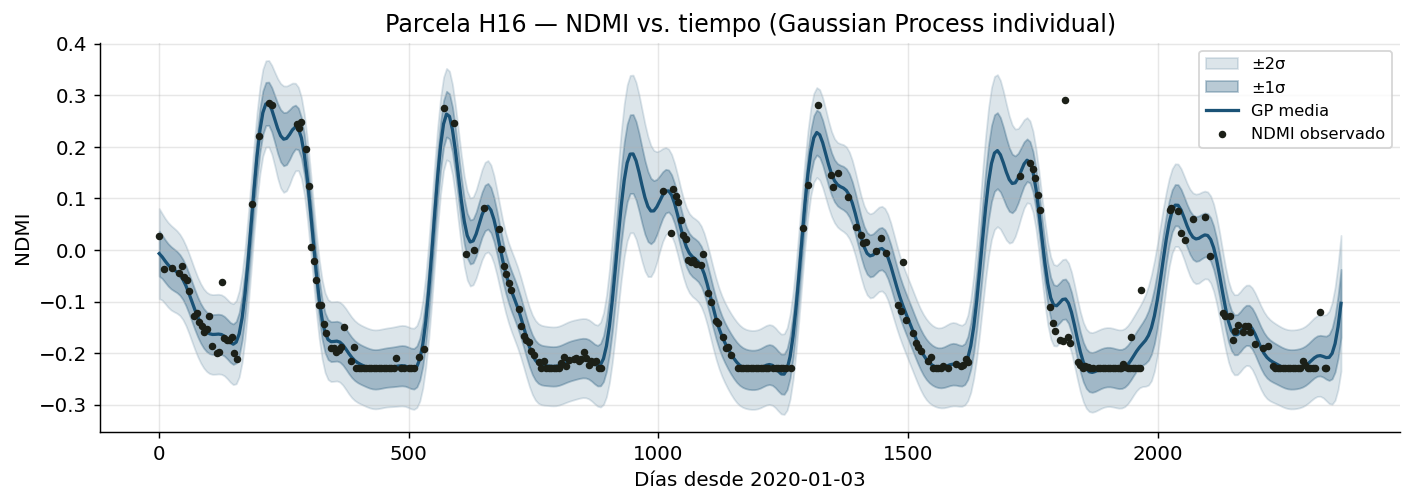

Última observación (2026-05-28): NDMI=-0.2297  →  z=+0.50  →  sin_estres


In [2]:
PARCEL_ID = "H16"
INDEX     = "NDMI"

series = load_parcel_series(PARCEL_ID, INDEX, SIGNALS_DIR, NORMALIZER_PATH)
gp_ind = ParcelGaussianProcess().fit(series.days, series.values)

days_grid   = np.linspace(series.days.min(), series.days.max() + 30, 400)
mean, std   = gp_ind.predict(days_grid)

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(days_grid, mean - 2*std, mean + 2*std, alpha=.15, color=INDEX_COLORS[INDEX], label="±2σ")
ax.fill_between(days_grid, mean - std,   mean + std,   alpha=.30, color=INDEX_COLORS[INDEX], label="±1σ")
ax.plot(days_grid, mean, color=INDEX_COLORS[INDEX], lw=1.8, label="GP media")
ax.scatter(series.days, series.values, color="#1C2018", s=10, zorder=5, label=f"{INDEX} observado")
ax.set_title(f"Parcela {PARCEL_ID} — {INDEX} vs. tiempo (Gaussian Process individual)")
ax.set_xlabel(f"Días desde {series.dates[0]}"); ax.set_ylabel(INDEX)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

last_day, last_value = float(series.days[-1]), float(series.values[-1])
z, label = gp_ind.anomaly_score(last_day, last_value)
print(f"Última observación ({series.dates[-1]}): {INDEX}={last_value:.4f}  →  z={z:+.2f}  →  {label}")


**Validación holdout:** entrenamos el GP sin las últimas 6 fechas y
comparamos contra lo realmente observado — si el modelo predice bien lo
que ya pasó, confiamos más en lo que predice hacia adelante.


In [3]:
evaluate_holdout(series, holdout=6)


2026-06-21 00:24:38 [INFO] parcel_gp - -- Holdout (6 fechas) - H16 / NDMI --


2026-06-21 00:24:38 [INFO] parcel_gp -   2026-04-26  real=-0.2297  gp_media=-0.2189+-0.0440  z=0.25


2026-06-21 00:24:38 [INFO] parcel_gp -   2026-05-01  real=-0.2297  gp_media=-0.2168+-0.0477  z=0.27


2026-06-21 00:24:38 [INFO] parcel_gp -   2026-05-06  real=-0.2297  gp_media=-0.2153+-0.0520  z=0.28


2026-06-21 00:24:38 [INFO] parcel_gp -   2026-05-16  real=-0.1211  gp_media=-0.2148+-0.0607  z=-1.54


2026-06-21 00:24:38 [INFO] parcel_gp -   2026-05-26  real=-0.2297  gp_media=-0.2159+-0.0678  z=0.20


2026-06-21 00:24:38 [INFO] parcel_gp -   2026-05-28  real=-0.2297  gp_media=-0.2156+-0.0690  z=0.21


## 4. Agrupación por tipo de terreno

El catálogo **no tiene dato real de suelo/elevación**: `altitude_m` viene
en `0.0` para las 100 parcelas (placeholder sin datos en
`data/raw/parcels/parcelas.csv`). El proxy disponible es la **huella
espectral histórica** de cada parcela — el promedio 2020-2026 de sus 5
índices (`data/datasets/manifest.csv`). Dos parcelas con la misma huella
espectral comparten tipo de dosel y retención de agua durante años — una
variable de nivel, no el evento de estrés puntual que mide el GP.

El número de grupos no se elige a ojo: se compara el *silhouette score*
para varios valores de *k*.


Parcelas con huella espectral válida: 100


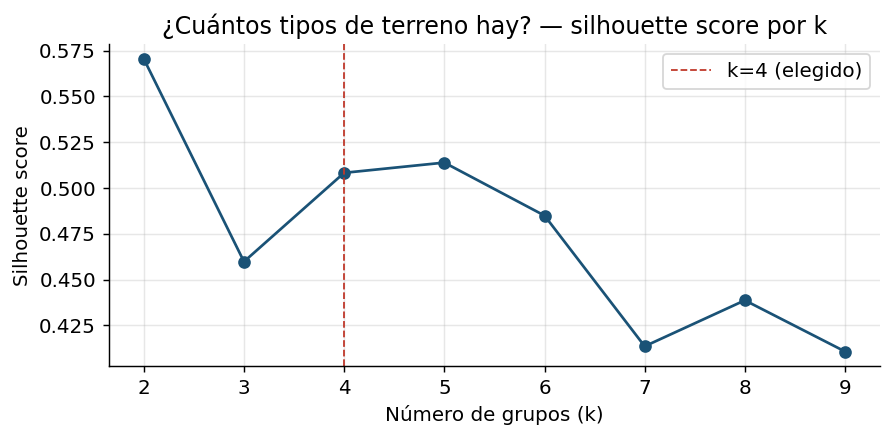

In [4]:
terrain_df = load_terrain_features(MANIFEST_CSV)
print(f"Parcelas con huella espectral válida: {len(terrain_df)}")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = StandardScaler().fit_transform(terrain_df[TERRAIN_FEATURES].values)
ks, sils = [], []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    ks.append(k); sils.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ks, sils, "o-", color="#1A5276")
ax.axvline(4, color="#C0392B", ls="--", lw=1, label="k=4 (elegido)")
ax.set_xlabel("Número de grupos (k)"); ax.set_ylabel("Silhouette score")
ax.set_title("¿Cuántos tipos de terreno hay? — silhouette score por k")
ax.legend(); plt.tight_layout(); plt.show()


`k=2` da el silhouette más alto (separa solo "baseline alto" vs. "bajo",
30/70 parcelas) — pero es demasiado burdo para distinguir matices de
terreno. **`k=4`** se eligió por mantener buena separación con grupos de
tamaño razonable (sin grupos de una sola parcela).


In [5]:
N_GROUPS = 4
result = cluster_parcels(terrain_df, N_GROUPS)
groups_lookup = result["parcel_to_group"]

summary_rows = []
for g, ids in result["groups"].items():
    sub = terrain_df[terrain_df["parcel_id"].isin(ids)]
    summary_rows.append({
        "grupo": g, "n_parcelas": len(ids),
        "NDMI_medio": sub["mean_ndmi"].mean(), "NDVI_medio": sub["mean_ndvi"].mean(),
        "EVI_medio": sub["mean_evi"].mean(),
    })
summary_df = pd.DataFrame(summary_rows).sort_values("NDMI_medio").reset_index(drop=True)
display(summary_df.style.format({"NDMI_medio": "{:+.4f}", "NDVI_medio": "{:.3f}", "EVI_medio": "{:.3f}"}))


,grupo,n_parcelas,NDMI_medio,NDVI_medio,EVI_medio
0,3,26,-0.0732,0.385,0.231
1,0,45,+0.0047,0.456,0.288
2,1,23,+0.0869,0.554,0.349
3,2,6,+0.2023,0.681,0.426


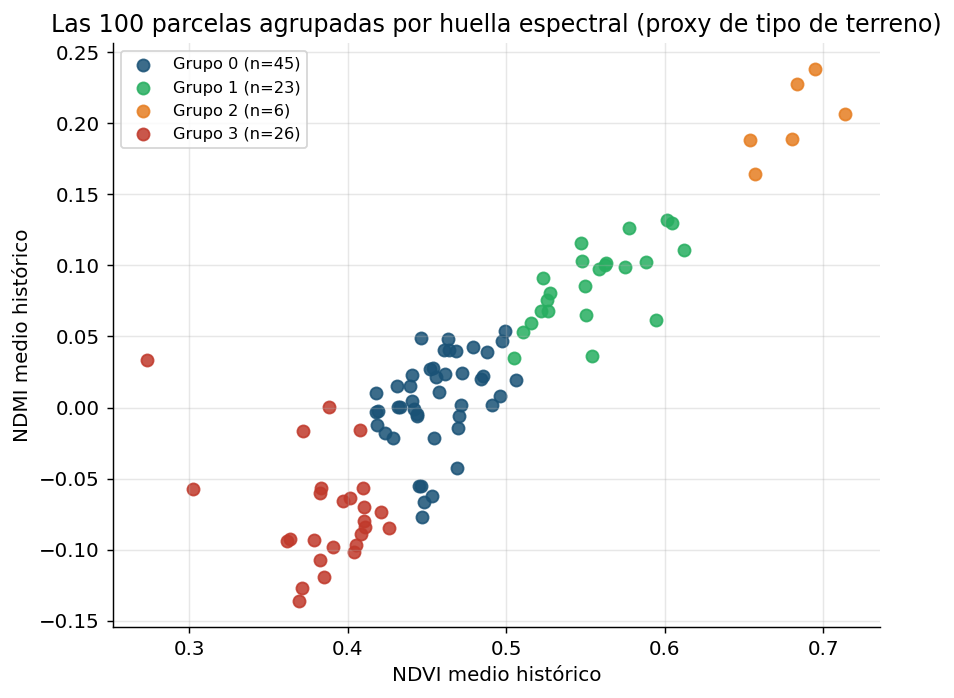

In [6]:
fig, ax = plt.subplots(figsize=(7, 5.5))
terrain_df_g = terrain_df.copy()
terrain_df_g["group"] = terrain_df_g["parcel_id"].map(groups_lookup)
for i, g in enumerate(sorted(terrain_df_g["group"].unique())):
    sub = terrain_df_g[terrain_df_g["group"] == g]
    ax.scatter(sub["mean_ndvi"], sub["mean_ndmi"], s=45, alpha=.85,
               color=GROUP_COLORS[i % len(GROUP_COLORS)], label=f"Grupo {g} (n={len(sub)})")
ax.set_xlabel("NDVI medio histórico"); ax.set_ylabel("NDMI medio histórico")
ax.set_title("Las 100 parcelas agrupadas por huella espectral (proxy de tipo de terreno)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()


## 5. Gaussian Process de grupo vs. individual

Para cada parcela del grupo se calcula su **baseline** (promedio
histórico propio) y se centra su serie. Las desviaciones de **todas** las
parcelas del grupo se promedian fecha por fecha (las 100 parcelas
comparten exactamente las mismas 277 fechas — mismo tile Sentinel-2,
mismo filtro de nubes) y se ajusta un solo GP sobre esa serie promediada.
Promediar entre parcelas — no solo concatenar — es lo que reduce el ruido
idiosincrático de una parcela con pocos eventos de estrés severo en su
propio historial.


In [7]:
EXAMPLE_PARCELS = ["H1", "H16", "H50", "H63", "H21"]
rows = []
for pid in EXAMPLE_PARCELS:
    r = compare_individual_vs_group(pid, GROUPS_JSON, INDEX, horizon_days=5,
                                     signals_dir=SIGNALS_DIR, normalizer_path=NORMALIZER_PATH)
    rows.append({
        "parcela": pid, "grupo": r["group_id"], "n_grupo": r["n_members"],
        "z_individual": r["individual"]["z"], "clase_individual": r["individual"]["label"],
        "z_grupo": r["group"]["z"], "clase_grupo": r["group"]["label"],
    })
comparison_df = pd.DataFrame(rows)
display(comparison_df.style.format({"z_individual": "{:+.2f}", "z_grupo": "{:+.2f}"}))


,parcela,grupo,n_grupo,z_individual,clase_individual,z_grupo,clase_grupo
0,H1,3,26,-0.00,sin_estres,+1.60,moderado
1,H16,3,26,+0.50,sin_estres,+1.66,moderado
2,H50,2,6,-0.13,sin_estres,+1.41,moderado
3,H63,3,26,+0.15,sin_estres,+0.54,sin_estres
4,H21,3,26,+0.05,sin_estres,-3.46,sin_estres


**Lectura:** varias parcelas que su propio historial individual no marca
como anómalas (`z_individual` bajo) sí lo son **respecto a otras parcelas
de terreno similar** en la misma fecha (`z_grupo` alto) — la vista de
grupo detecta una caída conjunta de NDMI que la vista aislada no ve. Esto
es justo el valor de agrupar por terreno: más muestras por distribución,
especialmente útil para parcelas con pocos eventos de estrés severo en su
propia historia.


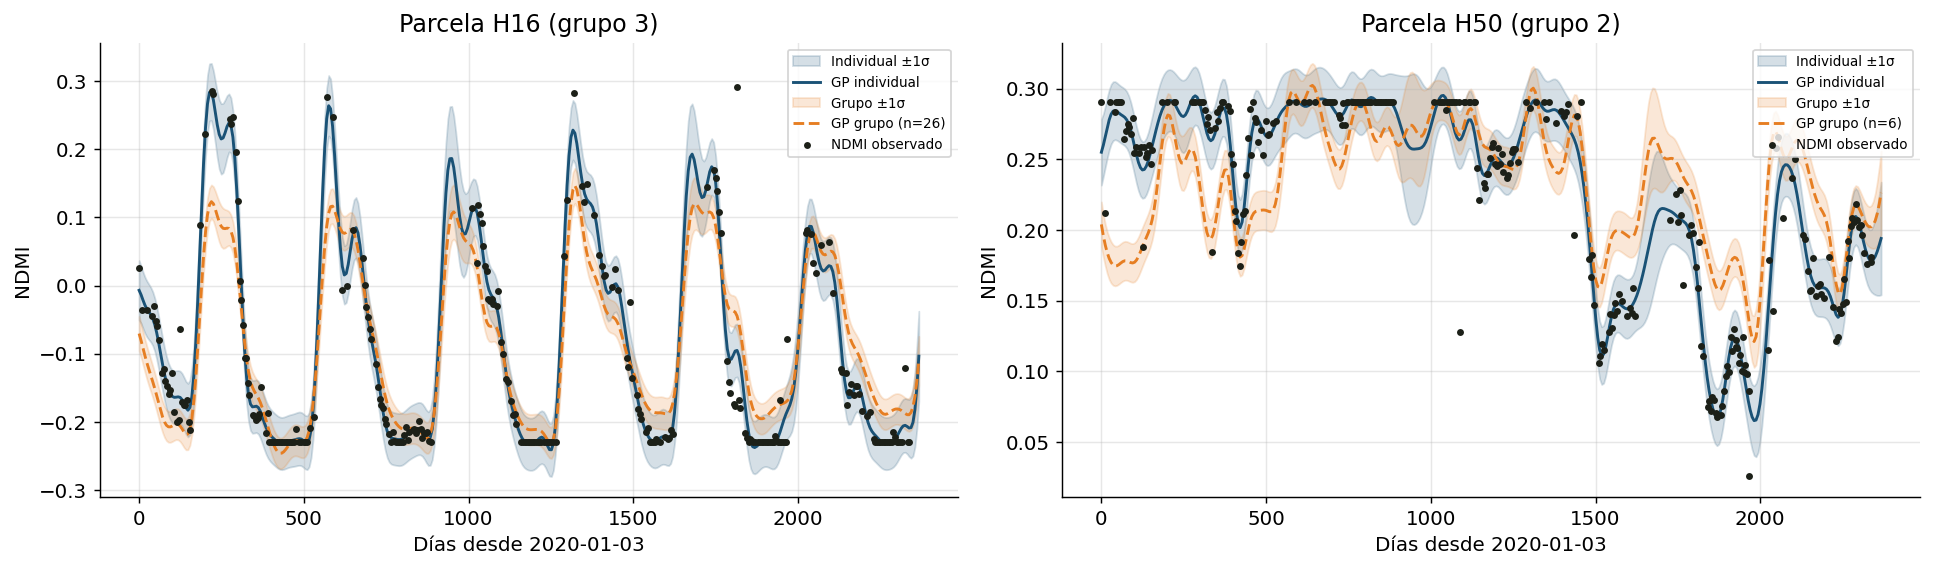

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=False)

for ax, pid in zip(axes, ["H16", "H50"]):
    gid = group_id_for_parcel(load_groups(GROUPS_JSON), pid)
    members = load_groups(GROUPS_JSON)["groups"][gid]

    s = load_parcel_series(pid, INDEX, SIGNALS_DIR, NORMALIZER_PATH)
    gp_i = ParcelGaussianProcess().fit(s.days, s.values)

    grp = load_group_series(gid, members, INDEX, SIGNALS_DIR, NORMALIZER_PATH)
    gp_g = fit_group_gp(grp)
    baseline = grp.baselines[pid]

    grid = np.linspace(s.days.min(), s.days.max() + 30, 400)
    mi, si = gp_i.predict(grid)
    md_, sg = gp_g.predict(grid)
    mg = baseline + md_

    ax.fill_between(grid, mi - si, mi + si, alpha=.18, color="#1A5276", label="Individual ±1σ")
    ax.plot(grid, mi, color="#1A5276", lw=1.6, label="GP individual")
    ax.fill_between(grid, mg - sg, mg + sg, alpha=.18, color="#E67E22", label="Grupo ±1σ")
    ax.plot(grid, mg, color="#E67E22", lw=1.6, ls="--", label=f"GP grupo (n={len(members)})")
    ax.scatter(s.days, s.values, color="#1C2018", s=8, zorder=5, label=f"{INDEX} observado")
    ax.set_title(f"Parcela {pid} (grupo {gid})")
    ax.set_xlabel(f"Días desde {s.dates[0]}"); ax.set_ylabel(INDEX)
    ax.legend(loc="upper right", fontsize=7.5)

plt.tight_layout(); plt.show()


**Validación holdout del GP de grupo** (grupo de H1, entrenando sin las
últimas 8 fechas pooled): confirma que la caída reciente es una tendencia
real que el modelo ya venía anticipando, no ruido de borde.


In [9]:
groups = load_groups(GROUPS_JSON)
gid = group_id_for_parcel(groups, "H1")
members = groups["groups"][gid]
grp = load_group_series(gid, members, INDEX, SIGNALS_DIR, NORMALIZER_PATH)

holdout = 8
train_days, train_vals = grp.days[:-holdout], grp.values[:-holdout]
test_days,  test_vals  = grp.days[-holdout:], grp.values[-holdout:]

gp_check = ParcelGaussianProcess().fit(train_days, train_vals)
mean_h, std_h = gp_check.predict(test_days)

holdout_df = pd.DataFrame({
    "day": test_days, "desviacion_real": test_vals,
    "gp_media": mean_h, "gp_std": std_h,
    "z": (mean_h - test_vals) / std_h,
})
display(holdout_df.style.format({"desviacion_real": "{:+.4f}", "gp_media": "{:+.4f}", "gp_std": "{:.4f}", "z": "{:+.2f}"}))


,day,desviacion_real,gp_media,gp_std,z
0,2295.000000,-0.0461,-0.0515,0.0259,-0.21
1,2300.000000,-0.0521,-0.0516,0.0277,+0.02
2,2305.000000,-0.0559,-0.0528,0.0297,+0.10
3,2310.000000,-0.0599,-0.0551,0.0318,+0.15
4,2315.000000,-0.0678,-0.0584,0.0337,+0.28
5,2325.000000,-0.0370,-0.0663,0.0367,-0.80
6,2335.000000,-0.0620,-0.0716,0.0383,-0.25
7,2337.000000,-0.0610,-0.0717,0.0385,-0.28


## 6. ¿Cómo se aplica esto a la clasificación final?

**Todavía no se fusiona con el E3 Stacking — es una decisión deliberada.**

| | Diagnóstico (dashboard) | Tendencias (dashboard) |
|---|---|---|
| Fuente | E3 Stacking, F1-macro=0.8868 | Gaussian Process (este experimento) |
| Qué responde | "¿Qué clase de estrés tiene esta parcela?" | "¿Qué tan atípica es la última observación?" |
| Estado | Modelo productivo, **sin tocar** | Capa de alerta/atención complementaria |

La integración completa significaría usar el z-score del GP para
**redefinir el criterio de etiquetado** (`api/features.py: label_window()`,
hoy un umbral NDMI fijo) y **reentrenar** el E3 Stacking. Es un cambio de
fondo al modelo productivo a días de la presentación final — **no se hizo**
para esta entrega.

En cambio, el GP se presenta como un **semáforo de alerta temprana**
(lenguaje del propio profesor en la reunión): cuando el grupo dice
"moderado" y el diagnóstico oficial dice "sin estrés", no es una
contradicción — es una señal de que esa parcela se está desviando de sus
pares *antes* de que el clasificador oficial lo capture. Una integración
más profunda (re-etiquetar y reentrenar) queda declarada como
**Experimento E**, trabajo futuro.


## 7. Limitaciones (honestidad > impresionar)

1. **No hay dato real de suelo/altitud** — el agrupamiento por terreno es
   un proxy (huella espectral histórica), no una clasificación edafológica.
2. **Recorte de percentil 1/99 en la normalización existente**
   (`src/processing/time_series_builder.py`) afecta a las parcelas más
   extremas (ej. H16): sus valores más bajos quedan "aplanados" en el
   percentil 1 global, sesgando levemente su baseline.
3. **El promedio entre parcelas del grupo no pondera por cuántas parcelas
   aportan dato en cada fecha** — simplificación válida para esta primera
   iteración, no un modelo jerárquico completo.
4. **Los cortes de 1σ/2σ son una elección razonable, no la única posible**
   — más principista que un percentil arbitrario, pero siguen siendo una
   decisión de diseño explícita.
5. Este experimento **no reemplaza el E3 Stacking**, que sigue siendo el
   modelo productivo del dashboard.

---
**Referencias:** `EXPERIMENTO_D_GAUSSIAN_PROCESS.md` · `src/models/gp/` ·
`api/trend.py` · pestaña "📈 Tendencias" del dashboard.
